In [112]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

In [113]:
from dotenv import load_dotenv
import os

_ = load_dotenv()

In [114]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage
from typing import TypedDict, Literal, List
from langchain_openai import ChatOpenAI  # or ChatAnthropic
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from typing import List
from langchain_groq import ChatGroq
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

In [115]:
class PlanItem(BaseModel):
    week: int = Field(description="Which week this item falls in")
    resource: str = Field(
        description="A single resource name or URL for this week. "
                     "If multiple resources apply, combine them into one "
                     "comma-separated string — do not return a list."
    )
    objective: str = Field(description="What the learner should achieve this week")

class WeeklyPlan(BaseModel):
    items: List[PlanItem]

In [116]:
from typing import Callable, TypeVar

T = TypeVar("T")

def invoke_with_retry(structured_llm, messages, max_retries: int = 2, node_name: str = ""):
    """
    Calls structured_llm.invoke(messages) with retries on failure.
    Logs which attempt succeeded, so repeated retries signal a schema/prompt
    that may need tightening further.
    """
    last_error = None
    for attempt in range(max_retries + 1):
        try:
            result = structured_llm.invoke(messages)
            if attempt > 0:
                print(f"[{node_name}] Succeeded on retry attempt {attempt + 1}")
            return result
        except Exception as e:
            last_error = e
            if attempt < max_retries:
                print(f"[{node_name}] Attempt {attempt + 1} failed ({type(e).__name__}), retrying...")
            continue
    print(f"[{node_name}] All {max_retries + 1} attempts failed.")
    raise last_error

In [117]:
class LearningPathState(TypedDict):
    # User inputs
    topic: str
    time_weeks: int
    level: Literal["beginner", "intermediate", "expert"]
    goal: str  # "job hunting", "just learning", etc.

    # Working state
    search_results: List[dict]      # raw resources found
    plan: List[PlanItem]
    generated_path: str              # final formatted output

    # Critique loop
    critique_feedback: str
    verdict: Literal["approve", "replan", "research"]
    iteration_count: int

In [118]:
from langchain_community.tools.tavily_search import TavilySearchResults

search_tool = TavilySearchResults(max_results=5)

class SearchResult(BaseModel):
    title: str = Field(description="Title of the resource")
    url: str = Field(description="URL of the resource")
    summary: str = Field(description="Brief summary of what this resource covers")
    resource_type: str = Field(description="Type of resource, e.g. course, article, video, documentation")

class SearchResults(BaseModel):
    results: List[SearchResult]

def search_node(state: LearningPathState) -> LearningPathState:
    topic = state["topic"]
    level = state["level"]

    query = f"{level} level learning resources for {topic}"
    raw_results = search_tool.invoke({"query": query})

    structured_results = [
        SearchResult(
            title=r.get("title", "Untitled"),
            url=r.get("url", ""),
            summary=r.get("content", "")[:300],
            resource_type="unknown"  # Tavily doesn't classify this
        )
        for r in raw_results
    ]

    return {**state, "search_results": structured_results}

In [119]:
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

structured_llm = llm.with_structured_output(WeeklyPlan)

def plan_node(state: LearningPathState) -> LearningPathState:
    topic = state["topic"]
    time_weeks = state["time_weeks"]
    level = state["level"]
    goal = state["goal"]
    search_results = state["search_results"]
    feedback = state.get("critique_feedback", "")

    resources_text = "\n".join(
    f"- {r.url}: {r.summary}"
    for r in search_results
        )

    system_prompt = (
        "You are an expert curriculum designer. Given a set of found resources, "
        "sequence them into a logical, prerequisite-aware learning path that fits "
        "the learner's time budget, level, and goal."
    )

    user_prompt = (
        f"Topic: {topic}\n"
        f"Time available: {time_weeks} weeks\n"
        f"Level: {level}\n"
        f"Goal: {goal}\n"
        f"Available resources:\n{resources_text}\n"
    )
    if feedback:
        user_prompt += f"\nPrevious plan feedback to address: {feedback}"

    response: WeeklyPlan = invoke_with_retry(
        structured_llm,
        [SystemMessage(content=system_prompt), HumanMessage(content=user_prompt)],
        node_name="plan"
    )

    return {
        **state,
        "plan": response.items  # now a clean list of PlanItem objects
    }

In [120]:
generate_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.7)

def generate_node(state: LearningPathState) -> LearningPathState:
    topic = state["topic"]
    level = state["level"]
    goal = state["goal"]
    time_weeks = state["time_weeks"]
    plan = state["plan"]  # List[PlanItem]

    plan_text = "\n".join(
        f"Week {item.week}: {item.resource} — {item.objective}"
        for item in plan
    )

    system_prompt = (
        "You are a friendly, encouraging learning coach. Turn the given weekly "
        "plan into a polished, motivating learning path write-up for the learner. "
        "Explain briefly why the sequence makes sense given their goal and level. "
        "Keep the tone professional and warm. Do not use emojis anywhere in the output."
    )


    user_prompt = (
        f"Topic: {topic}\n"
        f"Level: {level}\n"
        f"Goal: {goal}\n"
        f"Time: {time_weeks} weeks\n"
        f"Plan:\n{plan_text}\n"
    )

    response = generate_llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])

    return {**state, "generated_path": response.content}

In [121]:
class CritiqueResult(BaseModel):
    verdict: Literal["approve", "replan", "research"] = Field(
        description="approve if the plan is good, replan if sequencing/pacing is wrong "
                    "but resources are fine, research if resources themselves are poor/missing"
    )
    feedback: str = Field(
        description="Specific, actionable feedback explaining the verdict"
    )

structured_critique_llm = llm.with_structured_output(CritiqueResult)

def critique_node(state: LearningPathState) -> LearningPathState:
    topic = state["topic"]
    time_weeks = state["time_weeks"]
    level = state["level"]
    goal = state["goal"]
    plan = state["plan"]
    generated_path = state["generated_path"]
    iteration_count = state.get("iteration_count", 0)

    plan_text = "\n".join(
        f"Week {item.week}: {item.resource} — {item.objective}"
        for item in plan
    )

    system_prompt = (
        "You are a curriculum reviewer. Evaluate whether this learning path "
        "genuinely fits the learner's stated time budget, level, and goal. "
        "Check: Is pacing realistic? Are resources appropriate for the level? "
        "Does it actually serve the stated goal? "
        "IMPORTANT: This is a v1 learning plan, not a perfect one. Approve it if "
        "it is reasonably realistic and broadly appropriate, even if imperfect. "
        "Only recommend 'replan' for a genuine, significant mismatch (e.g., wildly "
        "unrealistic pacing, resources far above/below the learner's level, or a "
        "plan that doesn't serve the stated goal at all). Minor imperfections are "
        "expected and should not trigger a replan."
        )

    user_prompt = (
        f"Topic: {topic}\n"
        f"Time available: {time_weeks} weeks\n"
        f"Level: {level}\n"
        f"Goal: {goal}\n"
        f"Plan:\n{plan_text}\n"
        f"Generated write-up:\n{generated_path}\n"
    )

    result: CritiqueResult = invoke_with_retry(
        structured_critique_llm,
        [SystemMessage(content=system_prompt), HumanMessage(content=user_prompt)],
        node_name="critique"
    )

    return {
        **state,
        "verdict": result.verdict,
        "critique_feedback": result.feedback,
        "iteration_count": iteration_count + 1
    }

In [122]:
MAX_ITERATIONS = 3

def route_after_critique(state: LearningPathState) -> str:
    verdict = state["verdict"]
    iteration_count = state["iteration_count"]

    # Safety guard: force approval regardless of verdict once we hit the cap
    if iteration_count >= MAX_ITERATIONS:
        return "finalize"  # forced end — needs the disclaimer

    if verdict == "approve":
        return "finalize"  # clean end — finalize_node just passes it through
    elif verdict == "replan":
        return "plan"
    elif verdict == "research":
        return "search"

    return "finalize"

In [123]:
def finalize_node(state: LearningPathState) -> LearningPathState:
    verdict = state["verdict"]
    iteration_count = state["iteration_count"]
    generated_path = state["generated_path"]

    if iteration_count >= MAX_ITERATIONS and verdict != "approve":
        note = (
            "\n\n⚠️ Note: This plan went through the maximum number of "
            "refinement rounds and may still have some rough edges. "
            "Consider reviewing it manually."
        )
        generated_path = generated_path + note

    return {**state, "generated_path": generated_path}

In [124]:
from langgraph.graph import StateGraph, END

# Initialize the graph with our state schema
builder = StateGraph(LearningPathState)

# Register all nodes
builder.add_node("search", search_node)
builder.add_node("plan", plan_node)
builder.add_node("generate", generate_node)
builder.add_node("critique", critique_node)
builder.add_node("finalize", finalize_node)

# Set the entry point
builder.set_entry_point("search")

# Linear edges (unconditional)
builder.add_edge("search", "plan")
builder.add_edge("plan", "generate")
builder.add_edge("generate", "critique")
builder.add_edge("finalize", END)

# Conditional edge after critique
builder.add_conditional_edges(
    "critique",
    route_after_critique,
    {
        "plan": "plan",
        "search": "search",
        "finalize": "finalize"
    }
)

# Compile
conn = sqlite3.connect(":memory:", check_same_thread=False)
memory = SqliteSaver(conn)

graph = builder.compile(checkpointer=memory)

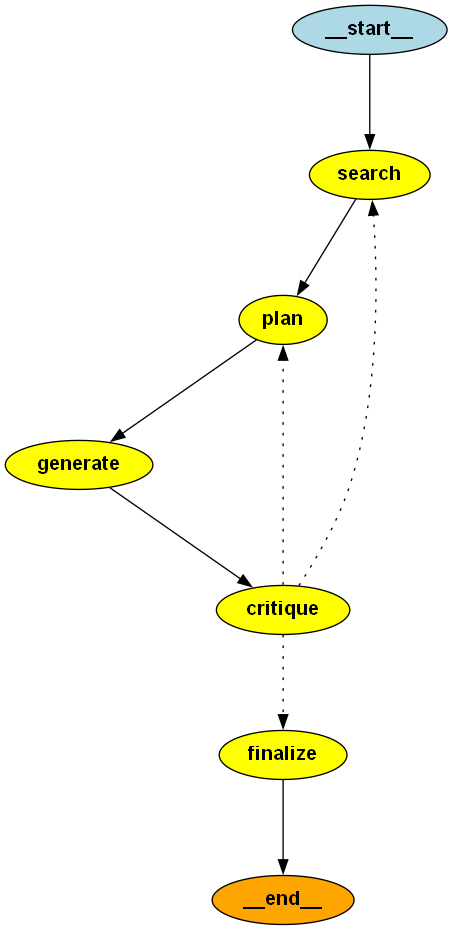

In [125]:
from IPython.display import Image
Image(graph.get_graph().draw_png())

In [126]:
initial_state: LearningPathState = {
    "topic": "Machine Learning Engineering",
    "time_weeks": 8,
    "level": "beginner",
    "goal": "job hunting",
    "search_results": [],
    "plan": [],
    "generated_path": "",
    "critique_feedback": "",
    "verdict": "approve",   # dummy default, overwritten by critique
    "iteration_count": 0
}


config = {"configurable": {"thread_id": "1"}}
final_state = graph.invoke(initial_state, config=config)
print(final_state["generated_path"])

**Machine‑Learning Engineering Learning Path – 8‑Week Beginner Program**  
*Goal: Build a solid foundation in machine learning and create a portfolio that will help you secure an entry‑level ML engineering position.*

---

## Why This Sequence Works  

You are starting from the basics of programming and aim to become job‑ready in a short period. The plan therefore:

1. **Establishes Python fundamentals first** – Python is the lingua franca of ML, and a comfortable grasp of variables, data structures, functions, and the core libraries (NumPy, pandas) is essential before any algorithmic work.  
2. **Introduces the conceptual workflow early** – Understanding the end‑to‑end ML pipeline (data collection → preprocessing → modeling → evaluation) gives context to every subsequent skill.  
3. **Builds hands‑on experience progressively** – Each week adds a new layer of practice—first on data wrangling, then on supervised models, followed by evaluation techniques, and finally unsupervised methods

In [127]:
config = {"configurable": {"thread_id": "1"}}

for step in graph.stream(initial_state, config=config):
    node_name = list(step.keys())[0]
    node_output = step[node_name]
    print(f"\n=== {node_name} ===")

    if node_name == "critique":
        print(f"Verdict: {node_output.get('verdict')}")
        print(f"Feedback: {node_output.get('critique_feedback')}")
        print(f"Iteration: {node_output.get('iteration_count')}")
    elif node_name == "search":
        print(f"Found {len(node_output.get('search_results', []))} resources")
    elif node_name == "plan":
        print(f"Plan has {len(node_output.get('plan', []))} items")
    elif node_name == "generate":
        print("Generated path (preview):", node_output.get('generated_path', '')[:150])
    elif node_name == "finalize":
        print("Final output:\n", node_output.get('generated_path', ''))

Deserializing unregistered type __main__.SearchResult from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'SearchResult')]
Deserializing unregistered type __main__.PlanItem from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'PlanItem')]



=== search ===
Found 5 resources

=== plan ===
Plan has 8 items

=== generate ===
Generated path (preview): **8‑Week Machine‑Learning Engineering Learning Path**  
*Beginner level – Focused on landing a machine‑learning engineering role*

---

### Overview  

=== critique ===
Verdict: replan
Feedback: The plan aims to take a complete beginner from zero to a job‑ready ML engineer in just eight weeks, which is overly optimistic. Learning Python fundamentals, core ML theory, hands‑on scikit‑learn, data‑cleaning, model evaluation, a Kaggle competition, and an end‑to‑end portfolio project all require more depth and practice than can be realistically achieved in a single week each for a novice. 

In addition, the resources listed are too vague or inappropriate for the learner’s level. 
- Week 1 points to a Kaggle "Python for Data Science" page, but the link is a generic discussion thread rather than a structured tutorial. 
- Weeks 2‑3 and Week 5 reference generic Coursera search results or 

In [128]:
state_snapshot = graph.get_state(config)
print(state_snapshot.values.get("iteration_count"))

2


In [ ]:
initial_state: LearningPathState = {
    "topic": "Machine Learning LangGraph",
    "time_weeks": 4,
    "level": "intermediate",
    "goal": "learning",
    "search_results": [],
    "plan": [],
    "generated_path": "",
    "critique_feedback": "",
    "verdict": "approve",   # dummy default, overwritten by critique
    "iteration_count": 0
}

In [ ]:
for step in graph.stream(initial_state):
    node_name = list(step.keys())[0]
    node_output = step[node_name]
    print(f"\n=== {node_name} ===")
    
    if node_name == "critique":
        print(f"Verdict: {node_output.get('verdict')}")
        print(f"Feedback: {node_output.get('critique_feedback')}")
        print(f"Iteration: {node_output.get('iteration_count')}")
    elif node_name == "search":
        print(f"Found {len(node_output.get('search_results', []))} resources")
    elif node_name == "plan":
        print(f"Plan has {len(node_output.get('plan', []))} items")
    elif node_name == "generate":
        print("Generated path (preview):", node_output.get('generated_path', '')[:150])
    elif node_name == "finalize":
        print("Final output:\n", node_output.get('generated_path', ''))

In [ ]:
state_snapshot = graph.get_state(config)
print(state_snapshot.values["generated_path"][:200])